In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import math
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

**U-NET**

I modelli di diffusione non generano un'immagine direttamente in un colpo solo, ma cercano di indovinare il rumore presente in un'immagine a un determinato step temporale t. Per farlo, si usa una U-Net.

**UNetBlock**

La U-Net è composta da tanti blocchi ripetuti. Questo blocco fa le seguenti operazioni:

1) **Convoluzione + GroupNorm + SiLU**: Estrae le caratteristiche geometriche dell'immagine.
2) **Iniezione del Tempo** (*time_mlp*): Poiché il livello di rumore cambia a ogni step t, la rete deve sapere a che punto della "sfocatura" si trova. Il tempo t viene convertito in un vettore e sommato direttamente alle caratteristiche dell'immagine (h = h + time_proj).
3) **Residual Block** (*residual_conv*): Somma l'input iniziale (x) all'output finale del blocco. Questo trucco previene la scomparsa del gradiente e aiuta la rete a non dimenticare i dettagli strada facendo.

In [ ]:
class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim=32, num_groups=8):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.gn1 = nn.GroupNorm(num_groups, out_channels)
        self.act1 = nn.SiLU()

        self.time_mlp = nn.Linear(time_dim, out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.gn2 = nn.GroupNorm(num_groups, out_channels)
        self.act2 = nn.SiLU()

        # Allinea i canali per la skip connection
        self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act1(self.gn1(self.conv1(x)))
        time_proj = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + time_proj
        h = self.act2(self.gn2(self.conv2(h)))

        return h + self.residual_conv(x)   # residual learning

**SinusoidalPositionEmbeddings**

Non usa parametri da addestrare, ma formule matematiche basate su funzioni seno e coseno a diverse frequenze.

Genera una firma geometrica unica per ogni step t.

Vantaggio: Poiché le funzioni seno/coseno sono continue, la rete capisce automaticamente che lo step 450 è vicinissimo allo step 451, migliorando la generalizzazione del modello anche su step temporali visti meno volte.

In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        # Calcolo delle frequenze
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        # Alterna funzioni seno e coseno
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

**ImprovedUNet**

Questa classe unisce i blocchi precedenti in una struttura speculare:
1) **Time Embedding**: Trasformo ogni step temporale (da 0 a 1000) in un vettore continuo usando la codifica sinusoidale.
2) **Encoder**: Riduce la risoluzione spaziale dell'immagine (usando *MaxPool2d*) ma aumenta il numero di canali (da 64 a 128), catturando informazioni sempre più astratte.
3) **Bottleneck**: Il punto più profondo dove le informazioni sono più compresse (256 canali).
4) **Decoder**: Ricostruisce la risoluzione originale dell'immagine (usando *ConvTranspose2d*).
5) **Skip Connections**: Servono a prendere le caratteristiche ad alta risoluzione dall'Encoder e "appiccicarle" direttamente nel Decoder. Questo permette di mantenere i dettagli nitidi dei contorni.

**Nota sul Condizionamento**: Nel metodo *forward*, l'input del modello è *torch.cat([x_t, x_cond], dim=1)*. Significa che l'immagine rumorosa *x_t* e l'immagine di guida *x_cond* vengono concatenate lungo i canali. La rete vede entrambe contemporaneamente!

In [ ]:
class ImprovedUNet(nn.Module):
    def __init__(self, in_channels=3, base_channels=64):
        super().__init__()

        # Dimensione espansa per l'embedding temporale (Standard DDPM)
        time_dim = base_channels * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_channels),
            nn.Linear(base_channels, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim)
        )

        # ENCODER
        # L'input concatenato avrà in_channels * 2 (immagine noisy + condizione)
        self.b1 = UNetBlock(in_channels * 2, base_channels, time_dim)
        self.down1 = nn.Conv2d(base_channels, base_channels, kernel_size=4, stride=2, padding=1)

        self.b2 = UNetBlock(base_channels, base_channels * 2, time_dim)
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1)

        # BOTTLENECK
        self.bottleneck = UNetBlock(base_channels * 2, base_channels * 4, time_dim)

        # DECODER
        self.up1 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.b3 = UNetBlock(base_channels * 4, base_channels * 2, time_dim) # in: 128(up) + 128(skip) = 256

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.b4 = UNetBlock(base_channels * 2, base_channels, time_dim)     # in: 64(up) + 64(skip) = 128

        self.out = nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, x_t, t, x_cond):
        # 1. Genera l'embedding temporale denso
        t_emb = self.time_mlp(t)

        # 2. Concatena lungo i canali
        x_input = torch.cat([x_t, x_cond], dim=1)

        # Encoder
        h1 = self.b1(x_input, t_emb)
        h2 = self.down1(h1)

        h2 = self.b2(h2, t_emb)
        h3 = self.down2(h2)

        # Bottleneck
        h3 = self.bottleneck(h3, t_emb)

        # Decoder
        h4 = self.up1(h3)
        h4 = torch.cat([h4, h2], dim=1)  # Skip connection da h2
        h4 = self.b3(h4, t_emb)

        h5 = self.up2(h4)
        h5 = torch.cat([h5, h1], dim=1)  # Skip connection da h1
        h5 = self.b4(h5, t_emb)

        return self.out(h5)

**DDPM**

Questa classe gestisce la vera e propria "matematica" del processo di diffusione: aggiungere rumore (*Forward*) e rimuoverlo (*Backward*).

**1. __init__**

Qui viene definita la "Noise Schedule" tramite un intervallo lineare di valori β. Vengono pre-calcolati tutti i coefficienti matematici (come α e i cumulativi alpha_cumprod) necessari per gestire il rumore.

Viene usato *register_buffer*: questi tensori non sono parametri che la rete deve aggiornare con il gradiente, ma costanti matematiche che devono comunque essere spostate sulla GPU insieme al modello.

**2. forward_diffusion** (Aggiunta del rumore)

Grazie alle proprietà matematiche dei DDPM, non serve applicare il rumore passo dopo passo per 1000 volte. Possiamo calcolare l'immagine corrotta allo step t direttamente in un solo colpo usando la formula...
Dove ϵ è rumore gaussiano puro. equazione.

**3. compute_loss**

- Prende un'immagine pulita x_0
- Sceglie un tempo t a caso e genera del rumore
- Inquina l'immagine tramite *forward_diffusion*
- Chiede alla U-Net (*self.network*) di indovinare quale rumore è stato aggiunto, passandole anche la condizione x_cond.
- Calcola l'errore quadratico medio (*MSELoss*) tra il rumore reale e quello predetto dalla rete.

**4. sample**

Questo è il processo inverso (*Denoising*). Parte da un'immagine di puro rumore gaussiano e, andando a ritroso dal tempo T=500 fino a 0, usa la U-Net per sottrarre progressivamente il rumore predetto, ricostruendo l'immagine un pezzetto alla volta.

In [ ]:
## VECCHIA VERSIONE
class DDPM(nn.Module):
    def __init__(self, network, n_steps=1000, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        self.network = network
        self.n_steps = n_steps

        beta = torch.linspace(beta_start, beta_end, n_steps)
        alpha = 1.0 - beta
        alpha_cumprod = torch.cumprod(alpha, dim=0)

        self.register_buffer('beta', beta)
        self.register_buffer('alpha', alpha)
        self.register_buffer('alpha_cumprod', alpha_cumprod)
        self.register_buffer('sqrt_alpha_cumprod', torch.sqrt(alpha_cumprod))
        self.register_buffer('sqrt_one_minus_alpha_cumprod', torch.sqrt(1.0 - alpha_cumprod))

    def forward_diffusion(self, x_0, t, noise):
        sqrt_alpha_cumprod = self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_cumprod = self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_alpha_cumprod * x_0 + sqrt_one_minus_alpha_cumprod * noise

    def compute_loss(self, x_0, x_cond):
        batch_size = x_0.shape[0]
        t = torch.randint(0, self.n_steps, (batch_size,), device=x_0.device)
        noise = torch.randn_like(x_0)

        x_t = self.forward_diffusion(x_0, t, noise)
        predicted_noise = self.network(x_t, t, x_cond)

        return nn.MSELoss()(predicted_noise, noise)

    @torch.no_grad()
    def sample(self, x_cond):
        self.network.eval()
        device = self.beta.device

        n_samples, channels, height, width = x_cond.shape
        x = torch.randn(n_samples, channels, height, width, device=device)

        for i in reversed(range(self.n_steps)):
            t = torch.full((n_samples,), i, dtype=torch.long, device=device)
            predicted_noise = self.network(x, t, x_cond)

            beta_t = self.beta[i]
            alpha_t = self.alpha[i]
            alpha_cumprod_t = self.alpha_cumprod[i]

            mean = (1 / torch.sqrt(alpha_t)) * (x - ((beta_t / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise))

            if i > 0:
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(beta_t)
                x = mean + sigma_t * noise
            else:
                x = mean

        self.network.train()
        return x

In [ ]:
## IMPOSTAZIONE CORRETTA DI SIGMA
class DDPM(nn.Module):
    def __init__(self, network, n_steps=200, beta_start=1e-4, beta_end=0.02): # FIX: Ridotti gli step totali a 200
        super().__init__()
        self.network = network
        self.n_steps = n_steps

        beta = torch.linspace(beta_start, beta_end, n_steps)
        alpha = 1.0 - beta
        alpha_cumprod = torch.cumprod(alpha, dim=0)
        alpha_cumprod_prev = torch.cat(
            [torch.tensor([1.0]), alpha_cumprod[:-1]]
        )

        self.register_buffer('alpha_cumprod_prev', alpha_cumprod_prev)
        self.register_buffer('posterior_variance', beta * (1 - alpha_cumprod_prev) / (1 - alpha_cumprod))
        self.register_buffer('beta', beta)
        self.register_buffer('alpha', alpha)
        self.register_buffer('alpha_cumprod', alpha_cumprod)
        self.register_buffer('sqrt_alpha_cumprod', torch.sqrt(alpha_cumprod))
        self.register_buffer('sqrt_one_minus_alpha_cumprod', torch.sqrt(1.0 - alpha_cumprod))

    def forward_diffusion(self, x_0, t, noise):
        sqrt_alpha_cumprod = self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_cumprod = self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_alpha_cumprod * x_0 + sqrt_one_minus_alpha_cumprod * noise

    def compute_loss(self, x_0, x_cond):
        batch_size = x_0.shape[0]
        t = torch.randint(0, self.n_steps, (batch_size,), device=x_0.device)
        noise = torch.randn_like(x_0)

        x_t = self.forward_diffusion(x_0, t, noise)
        predicted_noise = self.network(x_t, t, x_cond)

        return nn.MSELoss()(predicted_noise, noise)

    @torch.no_grad()
    def sample(self, batch_size, channels, height, width):
        self.network.eval()
        device = self.beta.device

        x = torch.randn(batch_size, channels, height, width, device=device)

        for i in reversed(range(self.n_steps)):
            t = torch.full((batch_size,), i, dtype=torch.long, device=device)
            predicted_noise = self.network(x, t.float())

            beta_t = self.beta[i]
            alpha_t = self.alpha[i]
            alpha_cumprod_t = self.alpha_cumprod[i]

            mean = (1 / torch.sqrt(alpha_t)) * (x - ((beta_t / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise))

            if i > 0:
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(self.posterior_variance[i])
                x = mean + sigma_t * noise
            else:
                x = mean

        self.network.train()
        return x

**PIPELINE DI TRAINING E TEST**

1) **Data Preparation**: Le immagini del dataset vengono ridimensionate a 32x32 pixel e normalizzate nell'intervallo [−1,1] (condizione ideale per i modelli di diffusione).
2) **Inizializzazione**: Vengono creati la U-Net, il DDPM (impostato a 500 step invece di 1000 per velocizzare) e l'ottimizzatore AdamW.
3) **Il Loop di Training**: Per ogni epoca, si scorre il dataset.
(Dettaglio cruciale: *loss = ddpm.compute_loss(x_0, x_0)* l'immagine target (x_0) viene passata anche come condizione. In questo specifico script, il modello si comporta come un autoencoder basato su diffusione: impara a ricostruire l'immagine guidato dall'immagine stessa.)
4) **Il Loop di Test**: Finita l'epoca di training, il modello viene messo in modalità *.eval()* per calcolare la loss sul dataset di test, verificando che stia imparando a generalizzare e non stia solo memorizzando i dati (overfitting).

In [ ]:
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Dispositivo in uso: {device}")

    torch.backends.cudnn.benchmark = True

    output_dir = "./risultati"
    os.makedirs(output_dir, exist_ok=True)

    # Trasformazioni specifiche per Oxford Pets (immagini grandi)
    transform_train = transforms.Compose([
        transforms.Resize(72),             # Rimpicciolisce tenendo le proporzioni
        transforms.RandomCrop(64),         # Prende un pezzo casuale di 64x64
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    transform_test = transforms.Compose([
        transforms.Resize(72),
        transforms.CenterCrop(64),         # nel test prendiamo sempre il centro
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    print("Caricamento del dataset Oxford-IIIT Pet (Train & Test)...")
    # TRAIN SET (Split 'trainval' contiene la maggior parte dei dati)
    train_dataset = datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform_train)
    train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)

    # TEST SET
    test_dataset = datasets.OxfordIIITPet(root='./data', split='test', download=True, transform=transform_test)
    test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=True, num_workers=2, pin_memory=True)

    nn_architecture = ImprovedUNet(in_channels=3).to(device)
    ddpm = DDPM(nn_architecture, n_steps=500).to(device)
    optimizer = optim.AdamW(ddpm.parameters(), lr=2e-4)

    scaler = torch.amp.GradScaler('cuda')

    epochs = 5
    print(f"Inizio del training ({epochs} epoche)...")

    for epoch in range(epochs):

        # FASE DI TRAINING
        ddpm.train()
        total_train_loss = 0
        for batch_idx, batch in enumerate(train_dataloader):
            x_0 = batch[0].to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                loss = ddpm.compute_loss(x_0, x_0)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_train_loss += loss.item()

        # FASE DI TEST
        ddpm.eval()
        total_test_loss = 0
        with torch.no_grad():
            for batch in test_dataloader:
                x_0_test = batch[0].to(device)
                with torch.amp.autocast('cuda'):
                    test_loss = ddpm.compute_loss(x_0_test, x_0_test)
                total_test_loss += test_loss.item()

        avg_train_loss = total_train_loss / len(train_dataloader)
        avg_test_loss = total_test_loss / len(test_dataloader)
        print(f"--- Fine Epoca {epoch+1} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} ---")

Dispositivo in uso: cpu
Caricamento del dataset Oxford-IIIT Pet (Train & Test)...
Inizio del training (5 epoche)...


/tmp/ipykernel_6540/1607429521.py:39: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler('cuda')
/tmp/ipykernel_6540/1607429521.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
/tmp/ipykernel_6540/1607429521.py:69: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):


--- Fine Epoca 1 | Train Loss: 0.2846 | Test Loss: 0.0850 ---


KeyboardInterrupt: 

**VISUALIZZAZIONE DEL RISULTATO**

1) Prendiamo un batch di 16 immagini reali dal Test Set (immagini che la rete non ha mai visto durante il training).
2) Le passiamo al metodo *ddpm.sample(cond_samples)*. Il modello genererà delle immagini cercando di seguire la guida fornita.
3) Denormalizzazione: Le immagini generate e quelle originali vengono riportate dall'intervallo [−1,1] a [0,1] tramite la formula (x + 1.0) / 2.0 in modo da poter essere visualizzate correttamente da *matplotlib*.
4) Viene mostrato il confronto: a sinistra le immagini guida originali, a destra le repliche generate dal modello di diffusione.


Test del condizionamento sulle immagini finali (prese dal Test Set)...


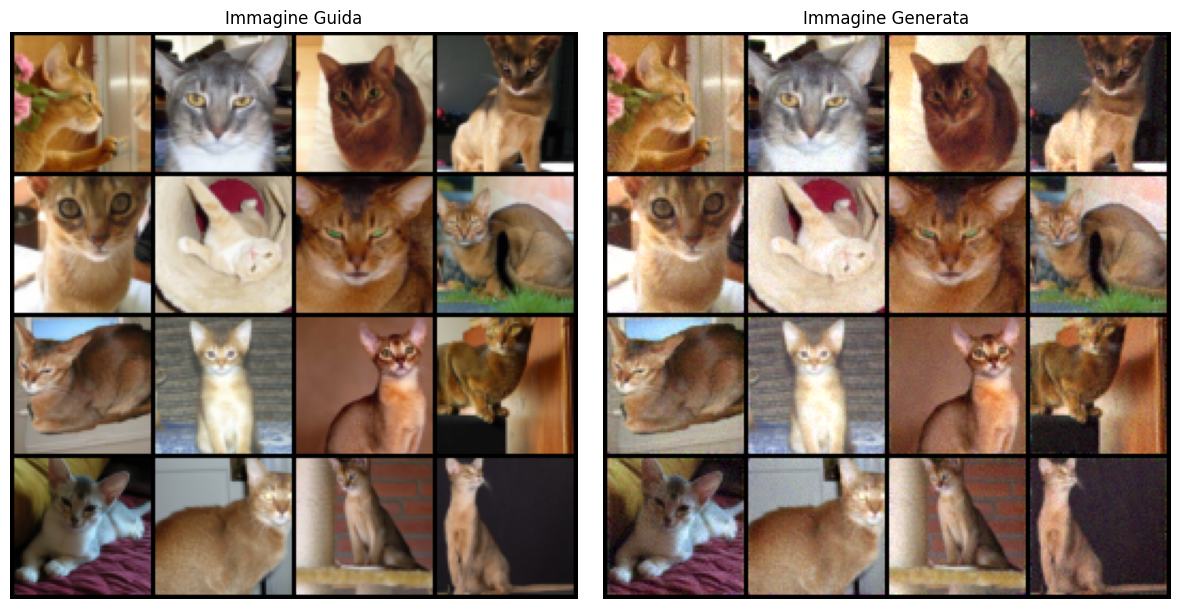

In [ ]:
    print("\nTest del condizionamento sulle immagini finali (prese dal Test Set)...")

    ddpm.eval()     # non calcolo più i gradienti

    real_batch, _ = next(iter(test_dataloader))   # estraiamo il batch dal test_dataloader
    cond_samples = real_batch[15:31].to(device)

    with torch.no_grad():
        generated_samples = ddpm.sample(cond_samples)

    cond_vis = torch.clamp((cond_samples.cpu() + 1.0) / 2.0, 0.0, 1.0)
    gen_vis = torch.clamp((generated_samples.cpu() + 1.0) / 2.0, 0.0, 1.0)

    grid_cond = make_grid(cond_vis, nrow=4).permute(1, 2, 0).numpy()
    grid_generated = make_grid(gen_vis, nrow=4).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(grid_cond)
    axes[0].set_title("Immagine Guida")
    axes[0].axis('off')

    axes[1].imshow(grid_generated)
    axes[1].set_title("Immagine Generata")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

**ALTRO DATASET**

In [ ]:
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Dispositivo in uso: {device}")

    torch.backends.cudnn.benchmark = True

    output_dir = "./risultati"
    os.makedirs(output_dir, exist_ok=True)

    # Trasformazioni (perfette per passare da 96x96 nativo a 64x64)
    transform_train = transforms.Compose([
        transforms.Resize(72),
        transforms.RandomCrop(64),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    transform_test = transforms.Compose([
        transforms.Resize(72),
        transforms.CenterCrop(64),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    print("Caricamento del dataset STL-10 (Train & Test)...")

    # TRAIN SET
    train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform_train)
    train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)

    # TEST SET
    test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=transform_test)
    test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=True, num_workers=2, pin_memory=True)

    # Inizializzazione Rete e Ottimizzatori
    nn_architecture = ImprovedUNet(in_channels=3).to(device)
    ddpm = DDPM(nn_architecture, n_steps=500).to(device)
    optimizer = optim.AdamW(ddpm.parameters(), lr=2e-4)

    scaler = torch.amp.GradScaler('cuda')

    epochs = 1
    print(f"Inizio del training ({epochs} epoche)...")

    for epoch in range(epochs):

        # FASE DI TRAINING
        ddpm.train()
        total_train_loss = 0
        for batch_idx, batch in enumerate(train_dataloader):
            # STL-10 restituisce tuple (immagine, etichetta). A noi serve solo l'immagine.
            x_0 = batch[0].to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                loss = ddpm.compute_loss(x_0, x_0)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_train_loss += loss.item()

        # FASE DI TEST
        ddpm.eval()
        total_test_loss = 0
        with torch.no_grad():
            for batch in test_dataloader:
                x_0_test = batch[0].to(device)
                with torch.amp.autocast('cuda'):
                    test_loss = ddpm.compute_loss(x_0_test, x_0_test)
                total_test_loss += test_loss.item()

        avg_train_loss = total_train_loss / len(train_dataloader)
        avg_test_loss = total_test_loss / len(test_dataloader)
        print(f"--- Fine Epoca {epoch+1} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} ---")

Dispositivo in uso: cuda
Caricamento del dataset STL-10 (Train & Test)...
Inizio del training (1 epoche)...
--- Fine Epoca 1 | Train Loss: 0.2451 | Test Loss: 0.0751 ---


**FINALE**

In [ ]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim
import random
import glob
import numpy as np
from torch.utils.data import ConcatDataset
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm

from google.colab import drive
drive.mount('/content/drive')

def set_seed(seed=42):
    """Fissa tutti i generatori di numeri casuali per la riproducibilità"""
    random.seed(seed)                      # Fissa il seed di Python base
    np.random.seed(seed)                   # Fissa il seed di Numpy
    torch.manual_seed(seed)                # Fissa il seed di PyTorch (CPU)
    torch.cuda.manual_seed(seed)           # Fissa il seed di PyTorch (GPU)
    torch.cuda.manual_seed_all(seed)       # Fissa il seed se hai più GPU


class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.mha = nn.MultiheadAttention(embed_dim=channels, num_heads=2, batch_first=True)
        self.ln = nn.LayerNorm(channels)
        self.ff_self = nn.Sequential(
            nn.LayerNorm(channels),
            nn.Linear(channels, channels),
            nn.GELU(),
            nn.Linear(channels, channels),
        )

    def forward(self, x):
        size = x.shape[-1]
        x_flat = x.reshape(-1, self.channels, size * size).transpose(1, 2)
        x_ln = self.ln(x_flat)
        attention_value, _ = self.mha(x_ln, x_ln, x_ln)
        attention_value = attention_value + x_flat
        attention_value = self.ff_self(attention_value) + attention_value
        return attention_value.transpose(1, 2).reshape(-1, self.channels, size, size)

class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim=32, num_groups=4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.gn1 = nn.GroupNorm(num_groups, out_channels)
        self.act1 = nn.SiLU()

        self.time_mlp = nn.Linear(time_dim, out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.gn2 = nn.GroupNorm(num_groups, out_channels)
        self.act2 = nn.SiLU()

        self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act1(self.gn1(self.conv1(x)))
        time_proj = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + time_proj
        h = self.act2(self.gn2(self.conv2(h)))
        return h + self.residual_conv(x)

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ImprovedUNet(nn.Module):
    def __init__(self, in_channels=3, cond_channels=3, base_channels=64):
        super().__init__()

        time_dim = base_channels * 4
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_channels),
            nn.Linear(base_channels, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim)
        )

        # Il primo blocco accetta in_channels (x_t) + cond_channels (immagine con stelle)
        self.inc = UNetBlock(in_channels + cond_channels, base_channels, time_dim)

        self.down1 = nn.Conv2d(base_channels, base_channels, 4, 2, 1)
        self.enc1 = UNetBlock(base_channels, base_channels * 2, time_dim)

        self.down2 = nn.Conv2d(base_channels*2, base_channels*2, 4, 2, 1)
        self.enc2 = UNetBlock(base_channels * 2, base_channels * 4, time_dim)

        self.down3 = nn.Conv2d(base_channels*4, base_channels*4, 4, 2, 1)

        self.bottleneck1 = UNetBlock(base_channels * 4, base_channels * 8, time_dim)
        self.attention = SelfAttention(base_channels * 8)
        self.bottleneck2 = UNetBlock(base_channels * 8, base_channels * 4, time_dim)

        self.up1 = nn.ConvTranspose2d(base_channels * 4, base_channels * 4, kernel_size=2, stride=2)
        self.dec1 = UNetBlock(base_channels * 8, base_channels * 2, time_dim)

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = UNetBlock(base_channels * 4, base_channels, time_dim)

        self.up3 = nn.ConvTranspose2d(base_channels, base_channels, kernel_size=2, stride=2)
        self.dec3 = UNetBlock(base_channels * 2, base_channels, time_dim)

        # L'output resta a 3 canali (deve predire il rumore dell'immagine target)
        self.out = nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, x_t, t, condition):
        x_input = torch.cat([x_t, condition], dim=1)

        t_emb = self.time_mlp(t.float())

        s1 = self.inc(x_input, t_emb)
        h = self.down1(s1)
        s2 = self.enc1(h, t_emb)
        h = self.down2(s2)
        s3 = self.enc2(h, t_emb)
        h = self.down3(s3)

        h = self.bottleneck1(h, t_emb)
        h = self.attention(h)
        h = self.bottleneck2(h, t_emb)

        h = self.up1(h)
        h = torch.cat([h, s3], dim=1)
        h = self.dec1(h, t_emb)

        h = self.up2(h)
        h = torch.cat([h, s2], dim=1)
        h = self.dec2(h, t_emb)

        h = self.up3(h)
        h = torch.cat([h, s1], dim=1)
        h = self.dec3(h, t_emb)

        return self.out(h)

class DDPM(nn.Module):
    def __init__(self, network, n_steps=200, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        self.network = network
        self.n_steps = n_steps

        beta = torch.linspace(beta_start, beta_end, n_steps)
        alpha = 1.0 - beta
        alpha_cumprod = torch.cumprod(alpha, dim=0)
        alpha_cumprod_prev = torch.cat(
            [torch.tensor([1.0]), alpha_cumprod[:-1]]
        )

        self.register_buffer('alpha_cumprod_prev', alpha_cumprod_prev)
        self.register_buffer('posterior_variance', beta * (1 - alpha_cumprod_prev) / (1 - alpha_cumprod))
        self.register_buffer('beta', beta)
        self.register_buffer('alpha', alpha)
        self.register_buffer('alpha_cumprod', alpha_cumprod)
        self.register_buffer('sqrt_alpha_cumprod', torch.sqrt(alpha_cumprod))
        self.register_buffer('sqrt_one_minus_alpha_cumprod', torch.sqrt(1.0 - alpha_cumprod))

    def forward_diffusion(self, x_0, t, noise):
        sqrt_alpha_cumprod = self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_cumprod = self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_alpha_cumprod * x_0 + sqrt_one_minus_alpha_cumprod * noise

    # Passiamo la condizione al compute_loss
    def compute_loss(self, x_0, condition):
        batch_size = x_0.shape[0]
        t = torch.randint(0, self.n_steps, (batch_size,), device=x_0.device)
        noise = torch.randn_like(x_0)

        x_t = self.forward_diffusion(x_0, t, noise)

        predicted_noise = self.network(x_t, t.float(), condition)

        return nn.MSELoss()(predicted_noise, noise)

    @torch.no_grad()
    # Il sample ora prende la condizione come punto di partenza
    def sample(self, condition):
        self.network.eval()
        device = self.beta.device

        batch_size, channels, height, width = condition.shape

        # Partiamo da puro rumore per il target
        x = torch.randn(batch_size, channels, height, width, device=device)

        for i in reversed(range(self.n_steps)):
            t = torch.full((batch_size,), i, dtype=torch.long, device=device)

            predicted_noise = self.network(x, t.float(), condition)

            beta_t = self.beta[i]
            alpha_t = self.alpha[i]
            alpha_cumprod_t = self.alpha_cumprod[i]

            mean = (1 / torch.sqrt(alpha_t)) * (x - ((beta_t / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise))

            if i > 0:
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(self.posterior_variance[i])
                x = mean + sigma_t * noise
            else:
                x = mean

        self.network.train()
        return x

def add_fake_stars(images, num_stars=15, max_radius=3):
    # Convertiamo in numpy per eliminare l'overhead dei tensori nei cicli for
    cond_images = images.detach().cpu().numpy().copy()
    B, C, H, W = cond_images.shape

    for b in range(B):
        for _ in range(num_stars):
            cx = random.randint(4, W - 5)
            cy = random.randint(4, H - 5)
            r = random.randint(1, max_radius)

            # 1. Corpo della stella
            for y in range(cy - r, cy + r + 1):
                for x in range(cx - r, cx + r + 1):
                    dist = ((x - cx) ** 2 + (y - cy) ** 2) ** 0.5
                    if dist <= r:
                        intensity = 1.0 - (dist / r) * 0.3
                        cond_images[b, :, y, x] = np.maximum(cond_images[b, :, y, x], intensity)

            # 2. Raggi di diffrazione
            if r >= 2:
                spike_length = r * 2
                for x in range(max(0, cx - spike_length), min(W, cx + spike_length + 1)):
                    dist = abs(x - cx)
                    intensity = 1.0 - (dist / spike_length) * 0.6
                    cond_images[b, :, cy, x] = np.maximum(cond_images[b, :, cy, x], intensity)
                for y in range(max(0, cy - spike_length), min(H, cy + spike_length + 1)):
                    dist = abs(y - cy)
                    intensity = 1.0 - (dist / spike_length) * 0.6
                    cond_images[b, :, y, cx] = np.maximum(cond_images[b, :, y, cx], intensity)

    return torch.from_numpy(cond_images)

if __name__ == "__main__":

    set_seed(42)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Dispositivo in uso: {device}")

    torch.backends.cudnn.benchmark = True

    output_dir = "/content/drive/MyDrive/Risultati_DDPM_cond"
    os.makedirs(output_dir, exist_ok=True)

    ####### PREPARAZIONE DATI

    transform_train = transforms.Compose([
        transforms.Resize(72),
        transforms.RandomCrop(64),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    print("Caricamento del dataset...")

    dataset_train = datasets.Flowers102(root='./data', split='train', download=True, transform=transform_train)
    dataset_val = datasets.Flowers102(root='./data', split='val', download=True, transform=transform_train)
    dataset_test = datasets.Flowers102(root='./data', split='test', download=True, transform=transform_train)

    full_train_dataset = ConcatDataset([dataset_train, dataset_test])
    train_dataloader = DataLoader(full_train_dataset, batch_size=64, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
    val_dataloader = DataLoader(dataset_val, batch_size=64, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)

    ###### INIZIALIZZAZIONE MODELLO E OTTIMIZZATORE

    epochs = 1000 # Spostato qui per evitare il NameError nello scheduler
    nn_architecture = ImprovedUNet(in_channels=3, base_channels=64).to(device)
    ddpm = DDPM(nn_architecture, n_steps=500).to(device)

    optimizer = optim.AdamW(ddpm.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    scaler = torch.cuda.amp.GradScaler()
    print(f"Inizio del training definitivo ({epochs} epoche)...")
    start_epoch = 0

    # Controllo Checkpoint
    checkpoints = glob.glob(os.path.join(output_dir, "ddpm_epoch_*.pth"))

    if checkpoints:
        checkpoints.sort(key=lambda x: int(x.split('_')[-1].split('.')[0]))
        last_checkpoint = checkpoints[-1]
        print(f"Trovato checkpoint precedente: {last_checkpoint}")

        checkpoint = torch.load(last_checkpoint, map_location=device)
        ddpm.load_state_dict(checkpoint["model"])
        optimizer.load_state_dict(checkpoint["optimizer"])
        scaler.load_state_dict(checkpoint["scaler"])
        scheduler.load_state_dict(checkpoint["scheduler"])
        start_epoch = checkpoint["epoch"] + 1
        print(f"Riprendo l'addestramento dall'epoca {start_epoch + 1}...")
    else:
        print("Nessun checkpoint trovato. Inizio l'addestramento da zero.")

    ###### LOOP DI TRAINING

    for epoch in range(start_epoch, epochs):
        ddpm.train()
        total_train_loss = 0

        pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1:03d}/{epochs}")
        for batch in pbar:
            x_0_cpu = batch[0] # Resta su CPU per adesso

            condition_cpu = add_fake_stars(x_0_cpu, num_stars=40)
            x_0 = x_0_cpu.to(device)
            condition = condition_cpu.to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                loss = ddpm.compute_loss(x_0, condition)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(ddpm.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            total_train_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = total_train_loss / len(train_dataloader)
        print(f"Epoch {epoch+1:03d} completata | Loss Media: {avg_train_loss:.4f}")

        scheduler.step()

        ###### VISUALIZZAZIONE OGNI 5 EPOCHE

        if (epoch + 1) % 20 == 0:
            print(f"\n---> Generazione test all'epoca {epoch+1}...")

            torch.save({
                "epoch": epoch,
                "model": ddpm.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scaler": scaler.state_dict(),
                "scheduler": scheduler.state_dict()
            }, os.path.join(output_dir, f"ddpm_epoch_{epoch+1}.pth"))

            ddpm.eval()
            with torch.no_grad():
                # Prendi il batch su CPU
                val_batch_cpu = next(iter(val_dataloader))[0][:8]

                # Applica le stelle su CPU
                val_condition_cpu = add_fake_stars(val_batch_cpu, num_stars=40)

                # Sposta in GPU solo ora
                val_batch = val_batch_cpu.to(device)
                val_condition = val_condition_cpu.to(device)

                # Generazione
                generated_samples = ddpm.sample(condition=val_condition)

            # Denormalizzazione per la visualizzazione [0, 1]
            cond_vis = torch.clamp((val_condition.cpu() + 1.0) / 2.0, 0.0, 1.0)
            gen_vis = torch.clamp((generated_samples.cpu() + 1.0) / 2.0, 0.0, 1.0)
            real_vis = torch.clamp((val_batch.cpu() + 1.0) / 2.0, 0.0, 1.0)

            # Creiamo una griglia comparativa: Riga 1 (Input con Stelle), Riga 2 (Output Ricostruito), Riga 3 (Target Pulito)
            everything = torch.cat([cond_vis, gen_vis, real_vis], dim=0)
            grid = make_grid(everything, nrow=8).permute(1, 2, 0).numpy()

            plt.figure(figsize=(12, 6))
            plt.imshow(grid)
            plt.title(f"Epoca {epoch+1} | In alto: Input (Stelle) -> In mezzo: Output (Modello) -> In basso: Target (Pulito)")
            plt.axis('off')
            plt.show()

    print("\nTraining Completato con Successo!")